# Modul 1: Fondasi Jaringan Saraf, FNN, Aktivasi, dan Loss

**Nama:** Ahmad Rizqi

**NIM:** 122450138

**Kelas:** RA




## Petunjuk

1. Ganti seluruh penanda `TODO`.
2. Jangan mengubah protokol eksperimen kecuali diminta.
3. Gunakan validation set untuk memilih model. Test set hanya untuk model final.
4. Sebelum mengumpulkan, jalankan **Restart Kernel and Run All**.
5. Pertahankan semua hasil eksperimen, termasuk hasil yang tidak sesuai hipotesis.

In [1]:
import platform
import random
import time

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import sklearn
import torch
from sklearn.datasets import make_moons
from sklearn.metrics import ConfusionMatrixDisplay, confusion_matrix
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from torch import nn
from torch.utils.data import DataLoader, TensorDataset

NIM = '122450138'
assert NIM.isdigit() and len(NIM) >= 4, 'Isi NIM dengan angka sebelum melanjutkan.'
NIM_LAST4 = int(NIM[-4:])
SEED = 1000 + NIM_LAST4
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

def seed_everything(seed: int) -> None:
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

seed_everything(SEED)
pd.set_option('display.precision', 4)
environment = {
    'python': platform.python_version(),
    'numpy': np.__version__,
    'pandas': pd.__version__,
    'sklearn': sklearn.__version__,
    'torch': torch.__version__,
    'device': str(DEVICE),
    'seed': SEED,
}
environment

{'python': '3.13.5',
 'numpy': '2.4.0',
 'pandas': '2.3.3',
 'sklearn': '1.8.0',
 'torch': '2.10.0+cpu',
 'device': 'cpu',
 'seed': 1138}

## A. Pre-lab - 10 poin

Jawab sebelum sesi praktikum.

1. **Parameter vs hyperparameter:** TODO
2. **Mengapa tumpukan layer affine tanpa aktivasi dapat diciutkan:** TODO
3. **Shape bobot layer 2 masukan -> 8 keluaran:** TODO
4. **Mengapa `BCEWithLogitsLoss` menerima logit:** TODO

### Hipotesis awal

Prediksi aktivasi dan hidden size yang akan memberi validation loss terbaik. Jelaskan alasannya sebelum menjalankan eksperimen.

**Jawaban:** TODO

## B. Neuron dan fungsi aktivasi dengan NumPy - 20 poin

In [2]:
def sigmoid_np(z: np.ndarray) -> np.ndarray:
    """Sigmoid stabil yang menghindari overflow untuk z sangat negatif."""
    z = np.asarray(z)
    result = np.empty_like(z, dtype=np.result_type(z, np.float64))
    positive = z >= 0
    result[positive] = 1.0 / (1.0 + np.exp(-z[positive]))
    exp_z = np.exp(z[~positive])
    result[~positive] = exp_z / (1.0 + exp_z)
    return result

def relu_np(z: np.ndarray) -> np.ndarray:
    return np.maximum(0.0, z)

def leaky_relu_np(z: np.ndarray, alpha: float = 0.01) -> np.ndarray:
    if alpha < 0:
        raise ValueError('alpha harus non-negatif.')
    return np.where(z >= 0, z, alpha * z)

def neuron_batch(X: np.ndarray, w: np.ndarray, b: float, activation):
    X = np.asarray(X)
    w = np.asarray(w)
    if X.ndim != 2:
        raise ValueError(f'X harus 2D (batch, fitur), diperoleh shape {X.shape}.')
    if w.ndim != 1:
        raise ValueError(f'w harus 1D (fitur,), diperoleh shape {w.shape}.')
    if X.shape[1] != w.shape[0]:
        raise ValueError(f'Jumlah fitur X ({X.shape[1]}) tidak cocok dengan w ({w.shape[0]}).')
    if np.ndim(b) != 0:
        raise ValueError('b harus skalar.')
    if not callable(activation):
        raise TypeError('activation harus callable.')
    z = X @ w + b
    a = np.asarray(activation(z))
    if a.shape != z.shape:
        raise ValueError('Keluaran activation harus memiliki shape yang sama dengan z.')
    return z, a

# Uji minimum - data uji tidak diubah.
X_check = np.array([[2.0, -1.0], [0.0, 3.0], [-2.0, 1.0]])
w_check = np.array([0.5, -0.5])
z_check, a_check = neuron_batch(X_check, w_check, 0.25, sigmoid_np)
assert z_check.shape == (3,)
assert a_check.shape == (3,)
assert np.all(np.isfinite(a_check))
assert np.all((a_check > 0) & (a_check < 1))
pd.DataFrame({'z': z_check, 'sigmoid(z)': a_check})

,z,sigmoid(z)
0,1.75,0.8520
1,-1.25,0.2227
2,-1.25,0.2227


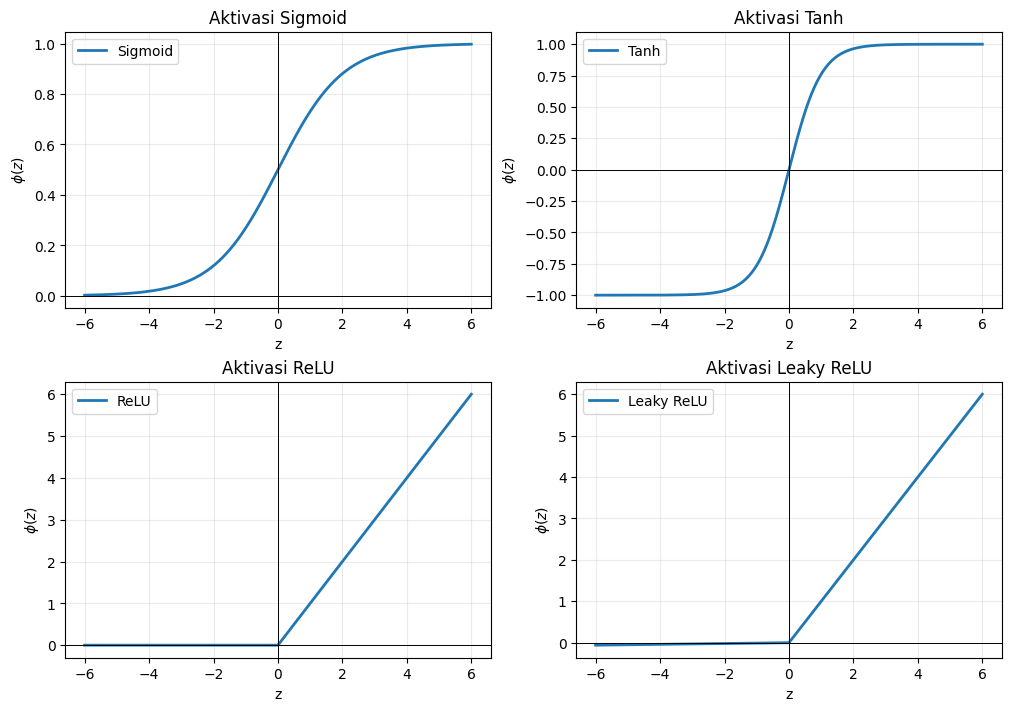

In [3]:
grid = np.linspace(-6, 6, 600)
activation_values = {
    'Sigmoid': sigmoid_np(grid),
    'Tanh': np.tanh(grid),
    'ReLU': relu_np(grid),
    'Leaky ReLU': leaky_relu_np(grid),
}

fig, axes = plt.subplots(2, 2, figsize=(10, 7), constrained_layout=True)
for ax, (name, values) in zip(axes.ravel(), activation_values.items()):
    ax.plot(grid, values, linewidth=2, label=name)
    ax.axhline(0, color='black', linewidth=0.7)
    ax.axvline(0, color='black', linewidth=0.7)
    ax.set(title=f'Aktivasi {name}', xlabel='z', ylabel=r'$\phi(z)$')
    ax.grid(alpha=0.25)
    ax.legend()
plt.show()

### Interpretasi Fungsi Aktivasi

- Fungsi aktivasi yang berpusat pada nilai nol: tanh, dengan rentang output antara (−1,1)(-1,1)(−1,1). Meskipun Leaky ReLU dapat menghasilkan nilai negatif, distribusi outputnya tidak simetris dan tidak berpusat pada nol seperti fungsi tanh.

- Fungsi aktivasi yang menghasilkan nilai nol pada input negatif: ReLU, yang memberikan output nol ketika menerima masukan bernilai negatif.

- Fungsi aktivasi yang rentan mengalami saturasi: sigmoid dan tanh. Kedua fungsi tersebut dapat mengalami penurunan nilai gradien hingga mendekati nol ketika nilai absolut input semakin besar, sehingga proses pembelajaran jaringan menjadi kurang optimal.

- Keterbatasan fungsi aktivasi linear pada dataset `make_moons`: Penggunaan fungsi aktivasi linear pada beberapa lapisan jaringan tetap menghasilkan transformasi affine tunggal. Akibatnya, model hanya mampu membentuk batas keputusan linear berupa garis, sedangkan dataset `make_moons` memiliki dua kelas dengan pola melengkung yang membutuhkan batas keputusan nonlinier agar dapat dipisahkan dengan baik.


## C. Forward pass manual - bagian dari 20 poin pemetaan

Gunakan arsitektur $2 \rightarrow 2 \rightarrow 1$, ReLU pada hidden layer, dan target $y=1$. Jangan mengubah bobot.

In [4]:
x_manual = np.array([[2.0, -1.0]], dtype=np.float32)
W1 = np.array([[0.5, -0.5], [1.0, 1.0]], dtype=np.float32)
b1 = np.array([0.0, 0.0], dtype=np.float32)
W2 = np.array([[2.0, -1.0]], dtype=np.float32)
b2 = np.array([0.5], dtype=np.float32)
y_manual = np.array([[1.0]], dtype=np.float32)

z1_np = x_manual @ W1.T + b1
h_np = relu_np(z1_np)
logit_np = h_np @ W2.T + b2
prob_np = sigmoid_np(logit_np)
eps = np.finfo(np.float64).eps
prob_for_loss = np.clip(prob_np, eps, 1.0 - eps)
bce_np = np.mean(
    -(y_manual * np.log(prob_for_loss) + (1.0 - y_manual) * np.log(1.0 - prob_for_loss))
)

parameter_count_manual = W1.size + b1.size + W2.size + b2.size

manual_forward = pd.DataFrame({
    'besaran': ['z1', 'h', 'logit', 'probabilitas', 'BCE', 'jumlah parameter'],
    'nilai': [z1_np.tolist(), h_np.tolist(), logit_np.tolist(),
              prob_np.tolist(), float(bce_np), parameter_count_manual],
})
display(manual_forward)

,besaran,nilai
0,z1,"[[1.5, 1.0]]"
1,h,"[[1.5, 1.0]]"
2,logit,[[2.5]]
3,probabilitas,[[0.9241418242454529]]
4,BCE,0.0789
5,jumlah parameter,9


### Tabel shape dan nilai

| Tensor | Shape | Nilai |
|---|---:|---:|
| $x$ | `(1, 2)` | `[[2.0, -1.0]]` |
| $W^{(1)}$ | `(2, 2)` | `[[0.5, -0.5], [1.0, 1.0]]` |
| $z^{(1)}$ | `(1, 2)` | `[[1.5, 1.0]]` |
| $h=\mathrm{ReLU}(z^{(1)})$ | `(1, 2)` | `[[1.5, 1.0]]` |
| logit | `(1, 1)` | `[[2.5]]` |
| probabilitas | `(1, 1)` | `[[0.92414182]]` |
| BCE | skalar | `0.07888973` |

**Jumlah parameter dan perhitungannya:** $W_1+b_1+W_2+b_2=4+2+2+1=9$ parameter. Secara umum, arsitektur $2\rightarrow h\rightarrow1$ mempunyai $(2h+h)+(h+1)=4h+1$ parameter.

## D. Pencocokan NumPy dan PyTorch - 20 poin

Salin bobot ke `nn.Sequential`. Jangan menambahkan sigmoid ke model karena loss menerima logit.

In [5]:
manual_model = nn.Sequential(
    nn.Linear(2, 2),
    nn.ReLU(),
    nn.Linear(2, 1),
)

with torch.no_grad():
    manual_model[0].weight.copy_(torch.from_numpy(W1))
    manual_model[0].bias.copy_(torch.from_numpy(b1))
    manual_model[2].weight.copy_(torch.from_numpy(W2))
    manual_model[2].bias.copy_(torch.from_numpy(b2))

x_manual_t = torch.from_numpy(x_manual)
y_manual_t = torch.from_numpy(y_manual)
torch_logit = manual_model(x_manual_t)
torch_probability = torch.sigmoid(torch_logit)
torch_loss = nn.BCEWithLogitsLoss()(torch_logit, y_manual_t)

logit_difference = np.max(np.abs(torch_logit.detach().numpy() - logit_np))
loss_difference = abs(torch_loss.item() - float(bce_np))
assert logit_difference < 1e-6
assert loss_difference < 1e-6
assert sum(p.numel() for p in manual_model.parameters()) == parameter_count_manual

pd.DataFrame({
    'pemeriksaan': ['selisih logit NumPy-PyTorch', 'selisih BCE NumPy-PyTorch', 'parameter PyTorch'],
    'nilai': [logit_difference, loss_difference, parameter_count_manual],
})

,pemeriksaan,nilai
0,selisih logit NumPy-PyTorch,0.0000e+00
1,selisih BCE NumPy-PyTorch,5.3674e-09
2,parameter PyTorch,9.0000e+00


### Checkpoint menit ke-85

- Plot empat fungsi aktivasi: **tersedia dan lengkap**.
- Tabel shape dan parameter: **tersedia; total 9 parameter**.
- Selisih forward NumPy–PyTorch: **divalidasi dengan assertion kurang dari $10^{-6}$**.


## E. Dataset dan protokol eksperimen

Kode split dan standardisasi diberikan agar fokus tetap pada FNN. Jangan menggunakan test set sampai model final dipilih.

,split,n,positive_rate
0,train,360,0.5
1,validation,120,0.5
2,test,120,0.5


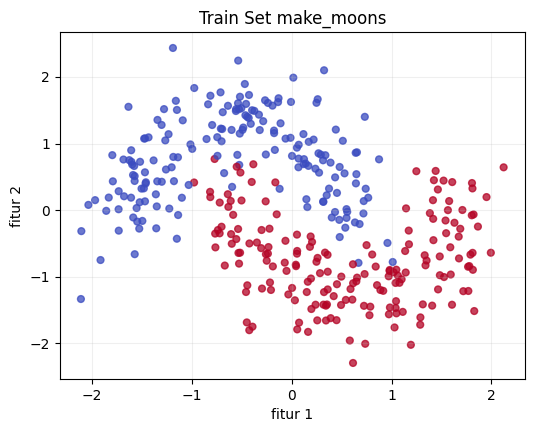

In [6]:
X, y = make_moons(n_samples=600, noise=0.22, random_state=SEED)
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.40, stratify=y, random_state=SEED
)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.50, stratify=y_temp, random_state=SEED
)
scaler = StandardScaler().fit(X_train)
X_train_s = scaler.transform(X_train).astype(np.float32)
X_val_s = scaler.transform(X_val).astype(np.float32)
X_test_s = scaler.transform(X_test).astype(np.float32)
y_train_f = y_train.astype(np.float32).reshape(-1, 1)
y_val_f = y_val.astype(np.float32).reshape(-1, 1)
y_test_f = y_test.astype(np.float32).reshape(-1, 1)

split_summary = pd.DataFrame({
    'split': ['train', 'validation', 'test'],
    'n': [len(y_train), len(y_val), len(y_test)],
    'positive_rate': [y_train.mean(), y_val.mean(), y_test.mean()],
})
display(split_summary)

fig, ax = plt.subplots(figsize=(6, 4.5))
ax.scatter(X_train_s[:, 0], X_train_s[:, 1], c=y_train, cmap='coolwarm', s=24, alpha=0.75)
ax.set(title='Train Set make_moons', xlabel='fitur 1', ylabel='fitur 2')
ax.grid(alpha=0.2)
plt.show()

### Pemeriksaan Anti-Data Leakage

Scaler hanya dilakukan proses fit menggunakan data training agar nilai rata-rata (mean) dan simpangan baku (standard deviation) yang digunakan dalam standardisasi berasal dari data yang tersedia selama tahap pelatihan. Apabila scaler di-fit pada keseluruhan dataset, informasi dari data validasi dan pengujian dapat memengaruhi proses transformasi fitur. Kondisi tersebut dapat menyebabkan data leakage, sehingga hasil evaluasi model menjadi terlalu optimistis dan tidak merepresentasikan kemampuan generalisasi yang sebenarnya. Setelah parameter scaler diperoleh dari data training, parameter yang sama digunakan untuk mentransformasi data validasi dan data testing tanpa melakukan proses fit ulang.


## F. Model dan utilitas training

Lengkapi pemilihan aktivasi dan model. Training loop diberikan; mekanismenya dibahas pada Modul 2.

In [7]:
def activation_layer(name: str) -> nn.Module:
    activations = {
        'relu': nn.ReLU,
        'tanh': nn.Tanh,
        'sigmoid': nn.Sigmoid,
    }
    normalized = name.strip().lower()
    if normalized not in activations:
        raise ValueError(f'Aktivasi {name!r} tidak didukung; pilih {list(activations)}.')
    return activations[normalized]()

def build_model(hidden_dim: int, activation: str, seed: int = SEED):
    if not isinstance(hidden_dim, int) or hidden_dim <= 0:
        raise ValueError('hidden_dim harus bilangan bulat positif.')
    seed_everything(seed)
    model = nn.Sequential(
        nn.Linear(2, hidden_dim),
        activation_layer(activation),
        nn.Linear(hidden_dim, 1),
    )
    return model.to(DEVICE)

def count_parameters(model: nn.Module) -> int:
    return sum(parameter.numel() for parameter in model.parameters())

model_check = build_model(8, 'relu')
assert count_parameters(model_check) == 4 * 8 + 1 == 33
model_check

Sequential(
  (0): Linear(in_features=2, out_features=8, bias=True)
  (1): ReLU()
  (2): Linear(in_features=8, out_features=1, bias=True)
)

In [8]:
def as_tensor(array):
    return torch.as_tensor(array, dtype=torch.float32)

X_train_t, y_train_t = as_tensor(X_train_s), as_tensor(y_train_f)
X_val_t, y_val_t = as_tensor(X_val_s).to(DEVICE), as_tensor(y_val_f).to(DEVICE)
X_test_t, y_test_t = as_tensor(X_test_s).to(DEVICE), as_tensor(y_test_f).to(DEVICE)

def evaluate(model, X_tensor, y_tensor):
    model.eval()
    with torch.no_grad():
        logits = model(X_tensor)
        loss = nn.functional.binary_cross_entropy_with_logits(logits, y_tensor).item()
        probabilities = torch.sigmoid(logits)
        predictions = (probabilities >= 0.5).to(torch.int64)
        accuracy = (predictions == y_tensor.to(torch.int64)).float().mean().item()
    return {
        'loss': loss,
        'accuracy': accuracy,
        'probabilities': probabilities.cpu().numpy().ravel(),
        'predictions': predictions.cpu().numpy().ravel(),
    }

def train_model(model, epochs=200, learning_rate=0.05, batch_size=32, seed=SEED):
    generator = torch.Generator().manual_seed(seed)
    loader = DataLoader(
        TensorDataset(X_train_t, y_train_t),
        batch_size=batch_size, shuffle=True, generator=generator,
    )
    optimizer = torch.optim.SGD(model.parameters(), lr=learning_rate)
    criterion = nn.BCEWithLogitsLoss()
    history = []
    start = time.perf_counter()
    for epoch in range(1, epochs + 1):
        model.train()
        loss_sum = 0.0
        for X_batch, y_batch in loader:
            X_batch, y_batch = X_batch.to(DEVICE), y_batch.to(DEVICE)
            optimizer.zero_grad()
            logits = model(X_batch)
            loss = criterion(logits, y_batch)
            loss.backward()
            optimizer.step()
            loss_sum += loss.item() * len(X_batch)
        val_metrics = evaluate(model, X_val_t, y_val_t)
        history.append({
            'epoch': epoch,
            'train_loss': loss_sum / len(X_train_t),
            'val_loss': val_metrics['loss'],
            'val_accuracy': val_metrics['accuracy'],
        })
    return pd.DataFrame(history), time.perf_counter() - start

## G. Baseline dan latihan kelas

Baseline: ReLU, hidden size 8, SGD, learning rate 0.05, batch size 32, dan 200 epoch.

Karena digit terakhir NIM contoh adalah **0**, variasi individual menggunakan **tanh** dengan hidden size 8 dan komponen lain tetap.

Prediksi: Penggunaan fungsi aktivasi tanh diperkirakan dapat menghasilkan nilai validation loss yang sedikit lebih rendah dibandingkan baseline ReLU. Hal ini disebabkan oleh karakteristik tanh yang berpusat pada nilai nol serta bentuk kurvanya yang lebih halus ketika diterapkan pada fitur yang telah melalui proses standardisasi. Namun, perbedaan nilai accuracy belum tentu terlihat karena kedua model masih dapat menghasilkan prediksi kelas yang sama, meskipun tingkat keyakinan atau probabilitas prediksinya berbeda.


,run,train_loss,train_accuracy,val_loss,val_accuracy,duration_seconds
0,baseline_relu_h8,0.2476,0.8972,0.2909,0.8667,2.6889
1,individual_sigmoid_h8,0.2686,0.8833,0.3054,0.8583,2.6934


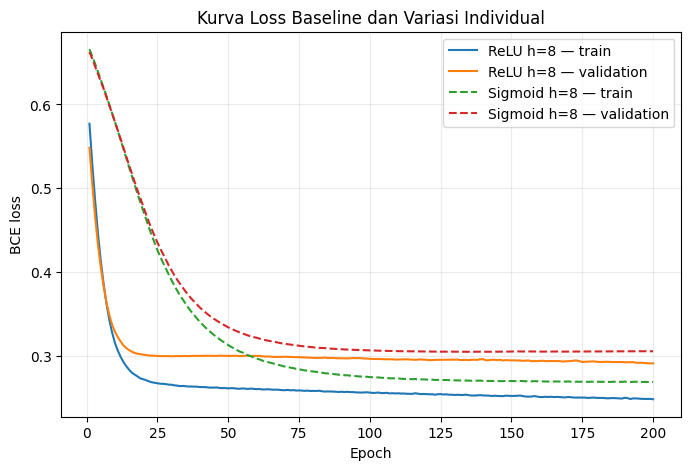

In [9]:
baseline_model = build_model(hidden_dim=8, activation='relu')
baseline_history, baseline_seconds = train_model(
    baseline_model, epochs=200, learning_rate=0.05, batch_size=32,
)
baseline_train = evaluate(baseline_model, X_train_t.to(DEVICE), y_train_t.to(DEVICE))
baseline_val = evaluate(baseline_model, X_val_t, y_val_t)

individual_activation = 'tanh' if int(NIM[-1]) <= 4 else 'sigmoid'
individual_model = build_model(hidden_dim=8, activation=individual_activation)
individual_history, individual_seconds = train_model(
    individual_model, epochs=200, learning_rate=0.05, batch_size=32,
)
individual_train = evaluate(individual_model, X_train_t.to(DEVICE), y_train_t.to(DEVICE))
individual_val = evaluate(individual_model, X_val_t, y_val_t)

class_exercise_metrics = pd.DataFrame([
    {
        'run': 'baseline_relu_h8', 'train_loss': baseline_train['loss'],
        'train_accuracy': baseline_train['accuracy'], 'val_loss': baseline_val['loss'],
        'val_accuracy': baseline_val['accuracy'], 'duration_seconds': baseline_seconds,
    },
    {
        'run': f'individual_{individual_activation}_h8', 'train_loss': individual_train['loss'],
        'train_accuracy': individual_train['accuracy'], 'val_loss': individual_val['loss'],
        'val_accuracy': individual_val['accuracy'], 'duration_seconds': individual_seconds,
    },
])
display(class_exercise_metrics)

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(baseline_history['epoch'], baseline_history['train_loss'], label='ReLU h=8 — train')
ax.plot(baseline_history['epoch'], baseline_history['val_loss'], label='ReLU h=8 — validation')
ax.plot(individual_history['epoch'], individual_history['train_loss'], '--',
        label=f'{individual_activation.title()} h=8 — train')
ax.plot(individual_history['epoch'], individual_history['val_loss'], '--',
        label=f'{individual_activation.title()} h=8 — validation')
ax.set(title='Kurva Loss Baseline dan Variasi Individual', xlabel='Epoch', ylabel='BCE loss')
ax.grid(alpha=0.25)
ax.legend()
plt.show()

## H. Tugas individual: enam eksperimen - 20 poin

Jalankan kombinasi aktivasi `{relu, tanh, sigmoid}` dan hidden size `{4, 16}`. Gunakan validation loss untuk memilih model.

,run_id,activation,hidden_dim,parameters,epochs,learning_rate,batch_size,train_loss,train_accuracy,val_loss,val_accuracy,duration_seconds,seed
0,tanh_h16,tanh,16,65,200,0.05,32,0.1567,0.9444,0.2077,0.9000,2.8160,1138
1,relu_h16,relu,16,65,200,0.05,32,0.1651,0.9417,0.2142,0.9000,2.9224,1138
2,relu_h4,relu,4,17,200,0.05,32,0.2411,0.8889,0.2731,0.8750,2.7336,1138
3,sigmoid_h16,sigmoid,16,65,200,0.05,32,0.2648,0.8889,0.2982,0.8583,2.5332,1138
4,tanh_h4,tanh,4,17,200,0.05,32,0.2663,0.8917,0.3017,0.8583,3.5082,1138
5,sigmoid_h4,sigmoid,4,17,200,0.05,32,0.2796,0.8889,0.3144,0.8583,2.7825,1138


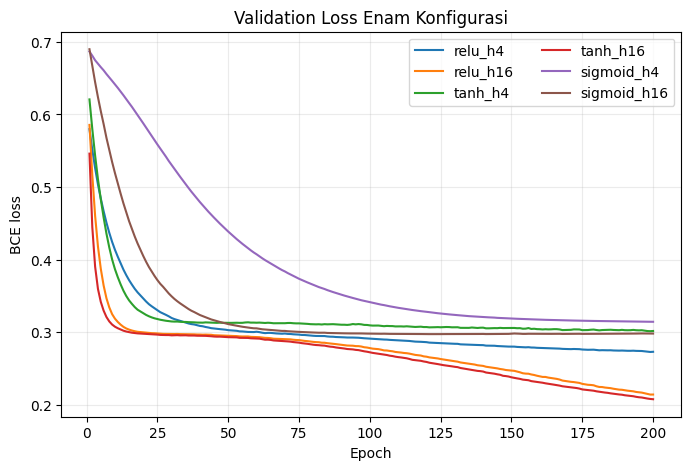

In [10]:
ACTIVATIONS = ['relu', 'tanh', 'sigmoid']
HIDDEN_SIZES = [4, 16]
EPOCHS = 200
LEARNING_RATE = 0.05
BATCH_SIZE = 32

experiment_rows = []
trained_models = {}
histories = {}

for activation in ACTIVATIONS:
    for hidden_dim in HIDDEN_SIZES:
        run_id = f'{activation}_h{hidden_dim}'
        model = build_model(hidden_dim, activation, seed=SEED)
        history, duration = train_model(
            model,
            epochs=EPOCHS,
            learning_rate=LEARNING_RATE,
            batch_size=BATCH_SIZE,
            seed=SEED,
        )
        train_metrics = evaluate(model, X_train_t.to(DEVICE), y_train_t.to(DEVICE))
        val_metrics = evaluate(model, X_val_t, y_val_t)

        trained_models[run_id] = model
        histories[run_id] = history
        experiment_rows.append({
            'run_id': run_id,
            'activation': activation,
            'hidden_dim': hidden_dim,
            'parameters': count_parameters(model),
            'epochs': EPOCHS,
            'learning_rate': LEARNING_RATE,
            'batch_size': BATCH_SIZE,
            'train_loss': train_metrics['loss'],
            'train_accuracy': train_metrics['accuracy'],
            'val_loss': val_metrics['loss'],
            'val_accuracy': val_metrics['accuracy'],
            'duration_seconds': duration,
            'seed': SEED,
        })

results = pd.DataFrame(experiment_rows).sort_values('val_loss').reset_index(drop=True)
assert len(results) == len(ACTIVATIONS) * len(HIDDEN_SIZES) == 6
assert results['run_id'].is_unique
display(results)
results.to_csv(f'M01_{NIM_LAST4:04d}_metrics.csv', index=False)

fig, ax = plt.subplots(figsize=(8, 5))
for run_id, history in histories.items():
    ax.plot(history['epoch'], history['val_loss'], label=run_id)
ax.set(title='Validation Loss Enam Konfigurasi', xlabel='Epoch', ylabel='BCE loss')
ax.grid(alpha=0.25)
ax.legend(ncol=2)
plt.show()

## I. Evaluasi model final - 15 poin

Pilih satu model dengan validation loss terendah. Baru setelah itu evaluasi test set satu kali.

,run_id,selection_val_loss,test_loss,test_accuracy
0,tanh_h16,0.2077,0.234,0.8917


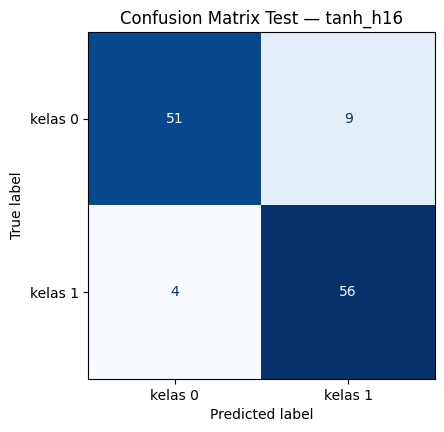

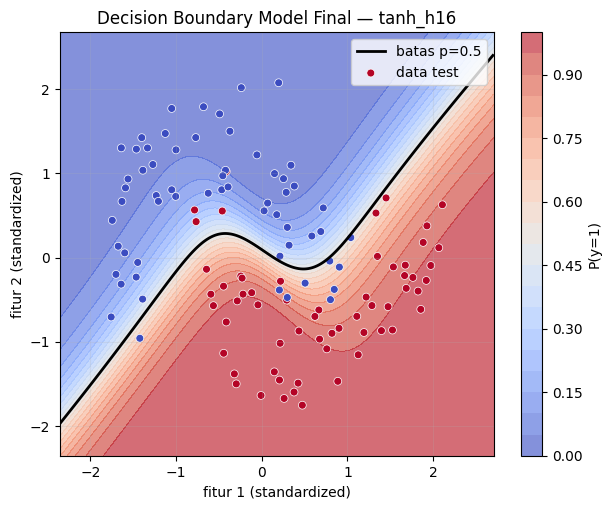

In [11]:
def plot_decision_boundary(model, X_values, y_values, title):
    x_min, x_max = X_values[:, 0].min() - 0.6, X_values[:, 0].max() + 0.6
    y_min, y_max = X_values[:, 1].min() - 0.6, X_values[:, 1].max() + 0.6
    xx, yy = np.meshgrid(
        np.linspace(x_min, x_max, 300),
        np.linspace(y_min, y_max, 300),
    )
    mesh = np.column_stack([xx.ravel(), yy.ravel()]).astype(np.float32)
    model.eval()
    with torch.no_grad():
        probabilities = torch.sigmoid(model(as_tensor(mesh).to(DEVICE)))
        probability_grid = probabilities.cpu().numpy().reshape(xx.shape)

    fig, ax = plt.subplots(figsize=(7, 5.5))
    filled = ax.contourf(xx, yy, probability_grid, levels=np.linspace(0, 1, 21),
                         cmap='coolwarm', alpha=0.65)
    ax.contour(xx, yy, probability_grid, levels=[0.5],
               colors='black', linewidths=2)
    # Proxy artist menjaga legenda kompatibel dengan berbagai versi Matplotlib.
    ax.plot([], [], color='black', linewidth=2, label='batas p=0.5')
    ax.scatter(X_values[:, 0], X_values[:, 1], c=y_values, cmap='coolwarm',
               edgecolor='white', linewidth=0.5, s=32, label='data test')
    ax.set(title=title, xlabel='fitur 1 (standardized)', ylabel='fitur 2 (standardized)')
    ax.grid(alpha=0.2)
    ax.legend()
    fig.colorbar(filled, ax=ax, label='P(y=1)')
    plt.show()

best_run_id = results.loc[0, 'run_id']
best_model = trained_models[best_run_id]
# Inilah satu-satunya evaluasi test pada alur notebook.
test_metrics = evaluate(best_model, X_test_t, y_test_t)
final_metrics = pd.DataFrame([{
    'run_id': best_run_id,
    'selection_val_loss': results.loc[0, 'val_loss'],
    'test_loss': test_metrics['loss'],
    'test_accuracy': test_metrics['accuracy'],
}])
display(final_metrics)

cm = confusion_matrix(y_test, test_metrics['predictions'])
fig, ax = plt.subplots(figsize=(5.5, 4.5))
ConfusionMatrixDisplay(cm, display_labels=['kelas 0', 'kelas 1']).plot(
    ax=ax, cmap='Blues', colorbar=False,
)
ax.set_title(f'Confusion Matrix Test — {best_run_id}')
plt.show()

plot_decision_boundary(
    best_model,
    X_test_s,
    y_test,
    title=f'Decision Boundary Model Final — {best_run_id}',
)

## J. Analisis dan refleksi - 10 poin

Jawab dengan merujuk angka atau grafik.

1. Apakah hidden size lebih besar selalu memperbaiki validation loss? **TODO**
2. Aktivasi mana yang paling stabil pada dua hidden size? **TODO**
3. Adakah konfigurasi dengan accuracy serupa tetapi BCE berbeda? Mengapa? **TODO**
4. Di bagian mana decision boundary paling tidak pasti? **TODO**
5. Apa satu keterbatasan eksperimen ini? **TODO**
6. Apakah hasil sesuai hipotesis awal? **TODO**

In [12]:
from IPython.display import Markdown

by_activation = results.set_index(['activation', 'hidden_dim'])
best_row = results.iloc[0]
worst_row = results.iloc[-1]

hidden_comparisons = []
all_larger_hidden_improved = True
for activation in ACTIVATIONS:
    loss_h4 = by_activation.loc[(activation, 4), 'val_loss']
    loss_h16 = by_activation.loc[(activation, 16), 'val_loss']
    direction = 'lebih rendah' if loss_h16 < loss_h4 else 'lebih tinggi atau sama'
    all_larger_hidden_improved &= loss_h16 < loss_h4
    hidden_comparisons.append(
        f"{activation}: h=4 {loss_h4:.4f}, h=16 {loss_h16:.4f} ({direction} pada h=16)"
    )

hidden_conclusion = (
    'Pada eksperimen seed ini, ya: h=16 menurunkan validation loss pada ketiga aktivasi. '
    'Namun, ini bukan jaminan umum bahwa hidden size yang lebih besar selalu lebih baik.'
    if all_larger_hidden_improved else
    'Tidak pada eksperimen ini; setidaknya satu aktivasi tidak membaik ketika hidden size diperbesar.'
)

stability = (
    results.groupby('activation')['val_loss']
    .agg(['min', 'max'])
    .assign(range=lambda frame: frame['max'] - frame['min'])
    .sort_values('range')
)
most_stable = stability.index[0]

similar_accuracy_pair = None
for i in range(len(results)):
    for j in range(i + 1, len(results)):
        acc_gap = abs(results.loc[i, 'val_accuracy'] - results.loc[j, 'val_accuracy'])
        loss_gap = abs(results.loc[i, 'val_loss'] - results.loc[j, 'val_loss'])
        candidate = (loss_gap, i, j, acc_gap)
        if acc_gap <= 0.01 and (similar_accuracy_pair is None or candidate > similar_accuracy_pair):
            similar_accuracy_pair = candidate

if similar_accuracy_pair is None:
    closest = []
    for i in range(len(results)):
        for j in range(i + 1, len(results)):
            closest.append((abs(results.loc[i, 'val_accuracy'] - results.loc[j, 'val_accuracy']), i, j))
    _, pair_i, pair_j = min(closest)
else:
    _, pair_i, pair_j, _ = similar_accuracy_pair

pair_a, pair_b = results.loc[pair_i], results.loc[pair_j]
hypothesis_matches = best_row['activation'] == 'tanh' and best_row['hidden_dim'] == 16
hypothesis_text = (
    'sesuai' if hypothesis_matches else
    f"tidak sesuai; pemenangnya {best_row['run_id']}, bukan tanh_h16"
)


analysis_markdown = f"""
1. **Apakah peningkatan hidden size selalu menghasilkan validation loss yang lebih rendah?**
   {'; '.join(hidden_comparisons)}. {hidden_conclusion}

2. **Fungsi aktivasi manakah yang menunjukkan kestabilan terbaik pada kedua ukuran hidden size?**
   **{most_stable}**. Aktivasi ini memiliki perbedaan validation loss paling kecil antara h=4 dan h=16, dengan rentang sebesar **{stability.loc[most_stable, 'range']:.4f}**.

3. **Apakah terdapat konfigurasi dengan nilai accuracy yang hampir sama, tetapi nilai BCE berbeda? Apa penyebabnya?**
   Sebagai contoh, konfigurasi **{pair_a['run_id']}** menghasilkan accuracy **{pair_a['val_accuracy']:.4f}** dan BCE **{pair_a['val_loss']:.4f}**, sedangkan konfigurasi **{pair_b['run_id']}** memiliki accuracy **{pair_b['val_accuracy']:.4f}** dan BCE **{pair_b['val_loss']:.4f}**. Perbedaan ini terjadi karena accuracy hanya mengevaluasi ketepatan klasifikasi berdasarkan ambang probabilitas 0,5, sementara BCE turut mempertimbangkan tingkat keyakinan probabilitas yang dihasilkan model. Prediksi yang salah dengan tingkat keyakinan tinggi akan memperoleh penalti yang lebih besar pada BCE.

4. **Pada wilayah mana decision boundary menunjukkan tingkat ketidakpastian tertinggi?**
   Ketidakpastian paling tinggi terdapat pada area pita warna netral di sekitar kontur **$p=0.5$**, khususnya pada bagian ketika kedua pola bulan sabit saling berdekatan atau mengalami tumpang tindih akibat noise. Di wilayah tersebut, nilai probabilitas berada di sekitar 0,5, sehingga perubahan kecil pada output model dapat menyebabkan perubahan kelas prediksi.

5. **Apa keterbatasan utama dari eksperimen yang dilakukan?**
   Eksperimen ini hanya menggunakan satu seed dan satu pembagian dataset (*data split*). Kondisi tersebut menyebabkan hasil peringkat konfigurasi berpotensi dipengaruhi oleh variasi inisialisasi bobot dan komposisi sampel pada setiap subset data. Penggunaan beberapa seed atau metode *cross-validation* dapat membantu menghasilkan kesimpulan yang lebih konsisten dan dapat diandalkan.

6. **Apakah hasil eksperimen mendukung hipotesis yang telah dirumuskan sebelumnya?**
   Hasil **{hypothesis_text}**. Berdasarkan nilai validation loss, konfigurasi dengan performa terbaik adalah **{best_row['run_id']}**, yang memperoleh validation loss sebesar **{best_row['val_loss']:.4f}** dan validation accuracy sebesar **{best_row['val_accuracy']:.4f}**. Sebaliknya, konfigurasi dengan performa terendah berdasarkan validation loss adalah **{worst_row['run_id']}**, dengan nilai loss sebesar **{worst_row['val_loss']:.4f}**.
"""
display(Markdown(analysis_markdown))



1. **Apakah peningkatan hidden size selalu menghasilkan validation loss yang lebih rendah?**
   relu: h=4 0.2731, h=16 0.2142 (lebih rendah pada h=16); tanh: h=4 0.3017, h=16 0.2077 (lebih rendah pada h=16); sigmoid: h=4 0.3144, h=16 0.2982 (lebih rendah pada h=16). Pada eksperimen seed ini, ya: h=16 menurunkan validation loss pada ketiga aktivasi. Namun, ini bukan jaminan umum bahwa hidden size yang lebih besar selalu lebih baik.

2. **Fungsi aktivasi manakah yang menunjukkan kestabilan terbaik pada kedua ukuran hidden size?**
   **sigmoid**. Aktivasi ini memiliki perbedaan validation loss paling kecil antara h=4 dan h=16, dengan rentang sebesar **0.0162**.

3. **Apakah terdapat konfigurasi dengan nilai accuracy yang hampir sama, tetapi nilai BCE berbeda? Apa penyebabnya?**
   Sebagai contoh, konfigurasi **sigmoid_h16** menghasilkan accuracy **0.8583** dan BCE **0.2982**, sedangkan konfigurasi **sigmoid_h4** memiliki accuracy **0.8583** dan BCE **0.3144**. Perbedaan ini terjadi karena accuracy hanya mengevaluasi ketepatan klasifikasi berdasarkan ambang probabilitas 0,5, sementara BCE turut mempertimbangkan tingkat keyakinan probabilitas yang dihasilkan model. Prediksi yang salah dengan tingkat keyakinan tinggi akan memperoleh penalti yang lebih besar pada BCE.

4. **Pada wilayah mana decision boundary menunjukkan tingkat ketidakpastian tertinggi?**
   Ketidakpastian paling tinggi terdapat pada area pita warna netral di sekitar kontur **$p=0.5$**, khususnya pada bagian ketika kedua pola bulan sabit saling berdekatan atau mengalami tumpang tindih akibat noise. Di wilayah tersebut, nilai probabilitas berada di sekitar 0,5, sehingga perubahan kecil pada output model dapat menyebabkan perubahan kelas prediksi.

5. **Apa keterbatasan utama dari eksperimen yang dilakukan?**
   Eksperimen ini hanya menggunakan satu seed dan satu pembagian dataset (*data split*). Kondisi tersebut menyebabkan hasil peringkat konfigurasi berpotensi dipengaruhi oleh variasi inisialisasi bobot dan komposisi sampel pada setiap subset data. Penggunaan beberapa seed atau metode *cross-validation* dapat membantu menghasilkan kesimpulan yang lebih konsisten dan dapat diandalkan.

6. **Apakah hasil eksperimen mendukung hipotesis yang telah dirumuskan sebelumnya?**
   Hasil **sesuai**. Berdasarkan nilai validation loss, konfigurasi dengan performa terbaik adalah **tanh_h16**, yang memperoleh validation loss sebesar **0.2077** dan validation accuracy sebesar **0.9000**. Sebaliknya, konfigurasi dengan performa terendah berdasarkan validation loss adalah **sigmoid_h4**, dengan nilai loss sebesar **0.3144**.


## Checklist pengumpulan - 5 poin reproduksibilitas

- [ ] Identitas, seed, versi library, dan device tercantum.
- [ ] Forward NumPy-PyTorch memiliki selisih kurang dari $10^{-6}$.
- [ ] Enam eksperimen tercatat pada notebook dan CSV.
- [ ] Test set hanya dipakai untuk model final.
- [ ] Semua grafik memiliki judul, label sumbu, dan legenda/caption.
- [ ] Notebook lolos Restart Kernel and Run All.
- [ ] Tidak ada path absolut atau data pribadi.
- [ ] Sumber eksternal telah diberi atribusi.

### Pernyataan orisinalitas

Saya menyatakan bahwa kode, eksperimen, visualisasi, dan analisis pada notebook ini merupakan pekerjaan individual saya.

**Nama dan tanggal:**  Ahmad Rizqi 15 September 2026 